In [2]:
import pandas as pd
import numpy as np

print("Notebook Ready")

Notebook Ready


In [3]:
cmu = pd.read_csv("DSL-StrongPasswordData.csv")

print(cmu.shape)

cmu.head()

(20400, 34)


,subject,sessionIndex,rep,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,...,H.a,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return
0,s002,1,1,0.1491,0.3979,0.2488,0.1069,0.1674,0.0605,0.1169,...,0.1349,0.1484,0.0135,0.0932,0.3515,0.2583,0.1338,0.3509,0.2171,0.0742
1,s002,1,2,0.1111,0.3451,0.2340,0.0694,0.1283,0.0589,0.0908,...,0.1412,0.2558,0.1146,0.1146,0.2642,0.1496,0.0839,0.2756,0.1917,0.0747
2,s002,1,3,0.1328,0.2072,0.0744,0.0731,0.1291,0.0560,0.0821,...,0.1621,0.2332,0.0711,0.1172,0.2705,0.1533,0.1085,0.2847,0.1762,0.0945
3,s002,1,4,0.1291,0.2515,0.1224,0.1059,0.2495,0.1436,0.1040,...,0.1457,0.1629,0.0172,0.0866,0.2341,0.1475,0.0845,0.3232,0.2387,0.0813
4,s002,1,5,0.1249,0.2317,0.1068,0.0895,0.1676,0.0781,0.0903,...,0.1312,0.1582,0.0270,0.0884,0.2517,0.1633,0.0903,0.2517,0.1614,0.0818


In [4]:
cmu.info()

<class 'pandas.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 34 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   subject          20400 non-null  str    
 1   sessionIndex     20400 non-null  int64  
 2   rep              20400 non-null  int64  
 3   H.period         20400 non-null  float64
 4   DD.period.t      20400 non-null  float64
 5   UD.period.t      20400 non-null  float64
 6   H.t              20400 non-null  float64
 7   DD.t.i           20400 non-null  float64
 8   UD.t.i           20400 non-null  float64
 9   H.i              20400 non-null  float64
 10  DD.i.e           20400 non-null  float64
 11  UD.i.e           20400 non-null  float64
 12  H.e              20400 non-null  float64
 13  DD.e.five        20400 non-null  float64
 14  UD.e.five        20400 non-null  float64
 15  H.five           20400 non-null  float64
 16  DD.five.Shift.r  20400 non-null  float64
 17  UD.five.Shift.r  20400 

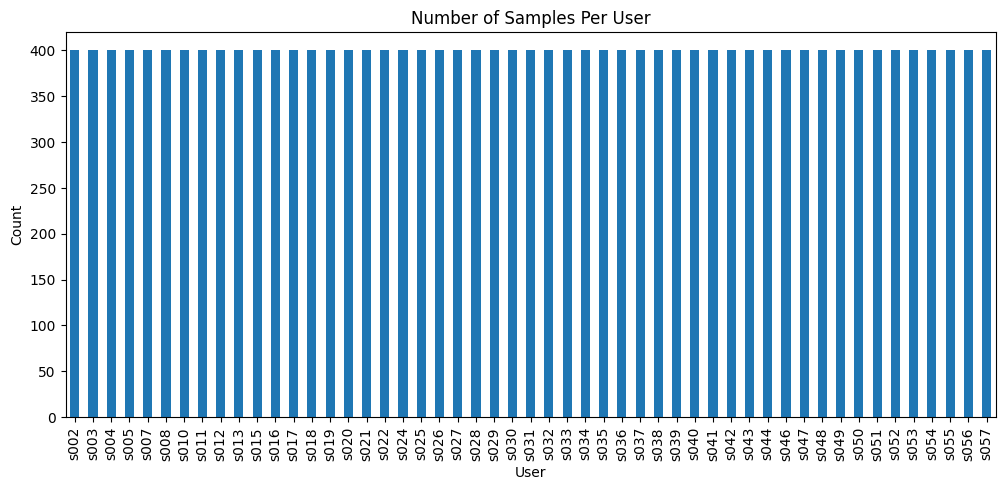

In [5]:
import matplotlib.pyplot as plt

# User Distribution Graph

cmu['subject'].value_counts().plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Number of Samples Per User")
plt.xlabel("User")
plt.ylabel("Count")

plt.show()

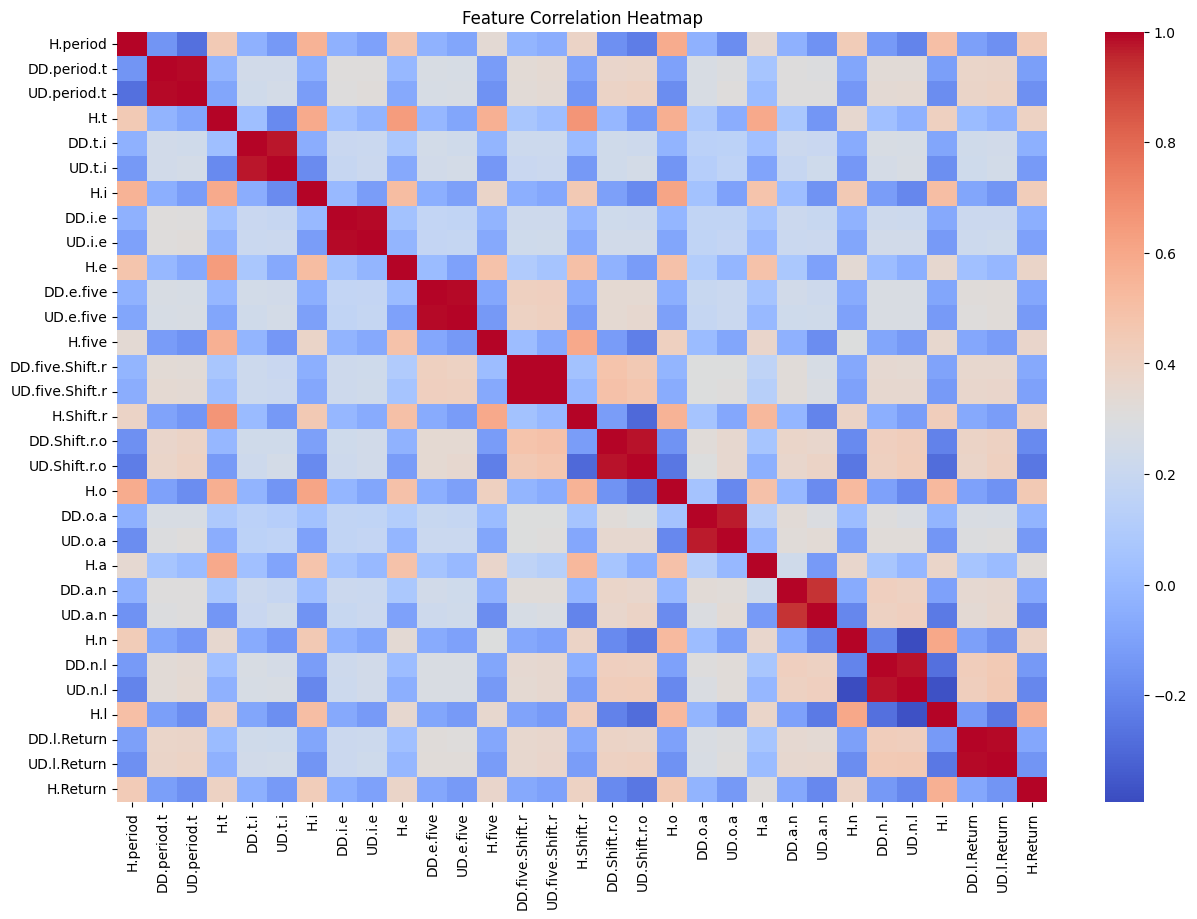

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

sns.heatmap(
    cmu.iloc[:,3:].corr(),
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [7]:
# ==================================
# Cell 6 : Features and Target
# ==================================

X = cmu.drop("subject", axis=1)
y = cmu["subject"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (20400, 33)
Target Shape: (20400,)


In [8]:
# ==================================
# Cell 7 : Train Test Split
# ==================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (16320, 33)
Test Shape: (4080, 33)


In [9]:
# ==================================
# Cell 8 : Random Forest Model
# ==================================

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [10]:
# ==================================
# Cell 9 : Accuracy
# ==================================

from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9375


In [11]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

        s002       0.85      0.85      0.85        72
        s003       0.92      0.87      0.90        69
        s004       0.90      0.95      0.92        73
        s005       0.96      0.96      0.96        73
        s007       0.88      0.85      0.87        54
        s008       0.93      0.86      0.89        87
        s010       0.96      0.97      0.96        97
        s011       0.97      0.91      0.94        75
        s012       0.93      0.91      0.92        93
        s013       0.95      0.96      0.95        72
        s015       0.95      0.90      0.92        87
        s016       0.94      0.98      0.96        85
        s017       1.00      0.99      0.99        82
        s018       0.97      0.84      0.90        73
        s019       0.99      0.99      0.99        80
        s020       0.99      0.81      0.89        86
        s021       0.87      0.95      0.91        86
        s022       0.99    

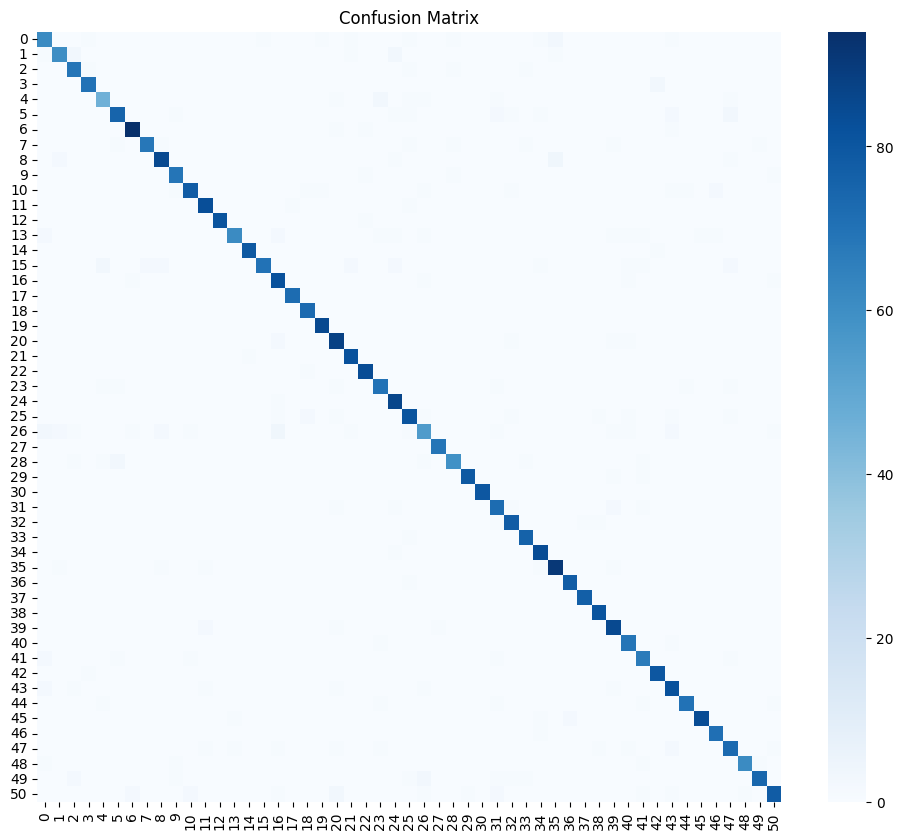

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

In [13]:
# Build user matrices like Q-SHEILD

meta_cols = ["subject", "sessionIndex", "rep"]

feat_cols = [
    c for c in cmu.columns
    if c not in meta_cols
]

user_matrices = {}

for uid, grp in cmu.groupby("subject"):
    user_matrices[uid] = grp[feat_cols].values.astype(float)

print("Number of users:", len(user_matrices))

first_user = list(user_matrices.keys())[0]

print("Example user:", first_user)
print("Shape:", user_matrices[first_user].shape)

Number of users: 51
Example user: s002
Shape: (400, 31)


In [ ]:
from sklearn.metrics import confusion_matrix

for user in sorted(y_test.unique()):

    y_true_bin = (y_test == user)
    y_pred_bin = (y_pred == user)

    tn, fp, fn, tp = confusion_matrix(
        y_true_bin,
        y_pred_bin
    ).ravel()

    print(f"\nUser: {user}")
    print("TP =", tp)
    print("TN =", tn)
    print("FP =", fp)
    print("FN =", fn)